# 01 — Exploration du corpus Archelec
Deux sources : `corpus_complet.csv` (textes OCR, 5 années) et `archelec.csv` (métadonnées complètes).

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')

# Corpus textes (5 années)
corpus = pd.read_csv('../data/metadata/corpus_complet.csv')

# Métadonnées complètes
meta = pd.read_csv('../data/metadata/archelec.csv', low_memory=False)

print(f'corpus_complet : {corpus.shape} — années : {sorted(corpus.year.unique())}')
print(f'archelec.csv   : {meta.shape}')
print(f'Colonnes archelec : {meta.columns.tolist()}')

corpus_complet : (21697, 4) — années : [np.int64(1973), np.int64(1978), np.int64(1981), np.int64(1988), np.int64(1993)]
archelec.csv   : (33031, 42)
Colonnes archelec : ['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour', 'cote', 'departement', 'departement-nom', 'departement-insee', 'identifiant de circonscription', 'images', 'pdf', 'ocr_url', 'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age', 'titulaire-age-calcule', 'titulaire-age-tranche', 'titulaire-profession', 'titulaire-mandat-en-cours', 'titulaire-mandat-passe', 'titulaire-associations', 'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste', 'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom', 'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule', 'suppleant-age-tranche', 'suppleant-profession', 'suppleant-mandat-en-cours', 'suppleant-mandat-passe', 'suppleant-associations', 'suppleant-autres-statuts', 'suppleant-soutien', 'suppleant-liste', 'suppleant-decorat

In [14]:
meta.columns

Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations'],
      dtype='str')

## 1. Distribution des documents par année (corpus textes)

      nb_docs  total_tokens  avg_tokens
year                                   
1973     3921       3114500       794.0
1978     5030       4075666       810.0
1981     3182       2093116       658.0
1988     3628       2002003       552.0
1993     5936       3881920       654.0


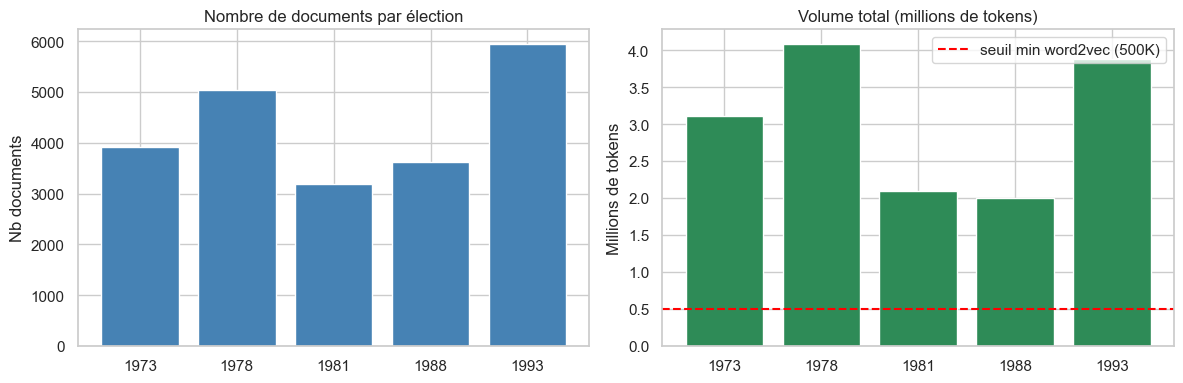

In [6]:
by_year = corpus.groupby('year').agg(
    nb_docs=('document_id', 'count'),
    total_tokens=('word_count', 'sum'),
    avg_tokens=('word_count', 'mean')
).round(0)
print(by_year)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(by_year.index.astype(str), by_year['nb_docs'], color='steelblue', edgecolor='white')
axes[0].set_title('Nombre de documents par élection')
axes[0].set_ylabel('Nb documents')

axes[1].bar(by_year.index.astype(str), by_year['total_tokens']/1e6, color='seagreen', edgecolor='white')
axes[1].set_title('Volume total (millions de tokens)')
axes[1].set_ylabel('Millions de tokens')
axes[1].axhline(0.5, color='red', linestyle='--', label='seuil min word2vec (500K)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/01_corpus_stats.png', dpi=150)
plt.show()

## 2. Distribution des longueurs de texte par année

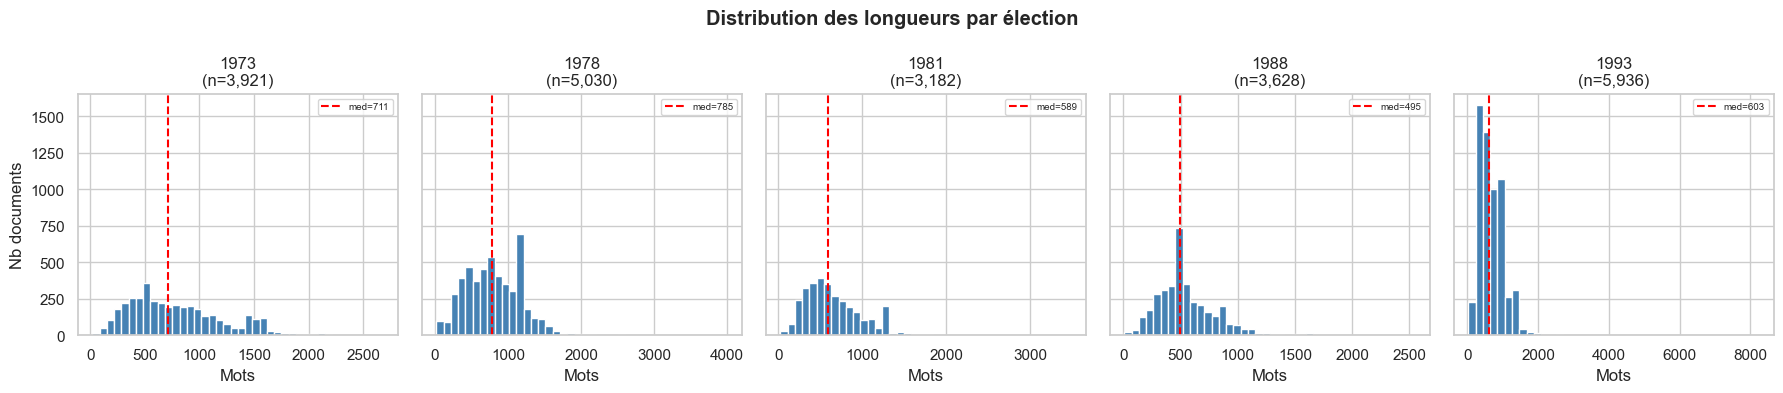

In [7]:
years = sorted(corpus['year'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(18, 4), sharey=True)

for ax, year in zip(axes, years):
    data = corpus[corpus['year'] == year]['word_count'].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f'{year}\n(n={len(data):,})')
    ax.set_xlabel('Mots')
    med = data.median()
    ax.axvline(med, color='red', linestyle='--', label=f'med={med:.0f}')
    ax.legend(fontsize=7)

axes[0].set_ylabel('Nb documents')
plt.suptitle('Distribution des longueurs par élection', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/01_longueurs.png', dpi=150)
plt.show()

## 3. Jointure corpus + métadonnées (parti politique)

In [8]:
# Jointure sur document_id / id
meta_sub = meta[['id', 'titulaire-soutien', 'titulaire-sexe', 
                  'titulaire-profession', 'departement-nom']].copy()
meta_sub = meta_sub.rename(columns={'id': 'document_id'})

df = corpus.merge(meta_sub, on='document_id', how='left')
match_rate = df['titulaire-soutien'].notna().mean()
print(f'Jointure réussie pour {match_rate:.1%} des documents')
print(f'Shape après jointure : {df.shape}')
df.head(3)

Jointure réussie pour 97.6% des documents
Shape après jointure : (21697, 8)


,document_id,year,text,word_count,titulaire-soutien,titulaire-sexe,titulaire-profession,departement-nom
0,EL067_L_1973_03_059_10_1_PF_04,1973,10me Circonscription\nElections Législatives -...,789,Front progressiste,homme,non mentionné,Nord
1,EL066_L_1973_03_044_05_1_PF_03,1973,Sciences Po / fonds CEVIPOF\nÉLECTIONS LÉGISLA...,563,non inscrit;républicain,homme,non mentionné,Loire-Atlantique
2,EL069_L_1973_03_080_02_1_PF_04,1973,Sciences Po / fonds CEVIPOF\n2e circonscriptio...,513,Alliance républicaine indépendante et libérale,homme,cadre juridique,Somme


## 4. Top partis représentés dans le corpus (années disponibles)

titulaire-soutien
non mentionné                                                          4040
Parti communiste français                                              2474
Parti socialiste                                                       1735
Front national                                                         1366
Lutte ouvrière                                                         1023
Rassemblement pour la République;Union pour la démocratie française     764
Rassemblement pour la République                                        637
Union pour la démocratie française;Rassemblement pour la République     455
Parti socialiste unifié                                                 441
Nouveaux écologistes du rassemblement nature et animaux                 387
Union des républicains de progrès                                       351
Verts;Génération écologie                                               293
Parti socialiste;Mouvement des radicaux de gauche                     

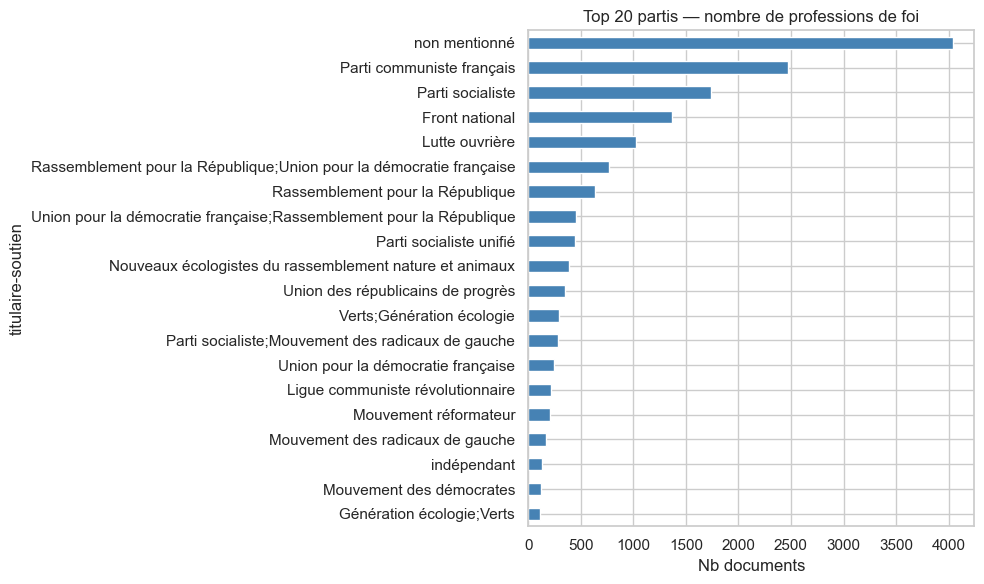

In [9]:
top_partis = df['titulaire-soutien'].value_counts().head(20)
print(top_partis.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
top_partis.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 partis — nombre de professions de foi')
ax.set_xlabel('Nb documents')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../results/figures/01_partis.png', dpi=150)
plt.show()

## 5. Évolution des grands partis dans le temps

famille  Autres   FN  Inconnu  PCF   PS  RPR  UDF/Centre  Écologistes
year                                                                 
1973       1516   99       78  772  870   11         575            0
1978       2001   42      203  948  957  575         234           70
1981       1136   45       61  582  888  390          43           37
1988       1612  544       89  553  242  533          31           24
1993       2083  651       99  630  352  880          98         1143


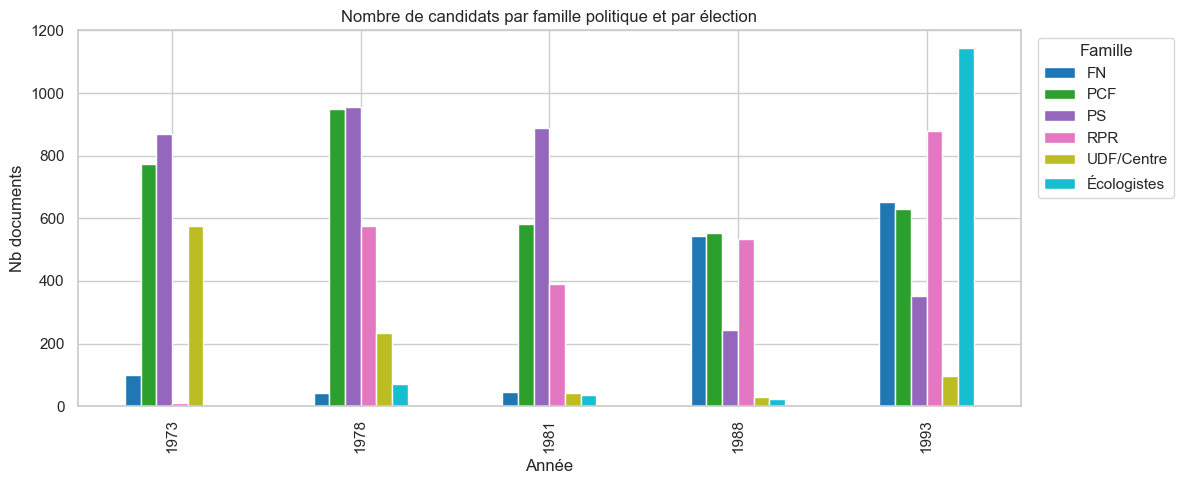

In [10]:
# Regrouper les partis en familles politiques
def famille_politique(parti):
    if pd.isna(parti): return 'Inconnu'
    p = str(parti).lower()
    if any(x in p for x in ['parti communiste', 'pcf', 'communiste']): return 'PCF'
    if any(x in p for x in ['parti socialiste', 'ps ', 'socialiste']): return 'PS'
    if any(x in p for x in ['rpr', 'rassemblement pour la république', 'gaulliste']): return 'RPR'
    if any(x in p for x in ['udf', 'républicains indépendants', 'centre']): return 'UDF/Centre'
    if any(x in p for x in ['front national', 'fn ']): return 'FN'
    if any(x in p for x in ['écolo', 'vert', 'environnement']): return 'Écologistes'
    return 'Autres'

df['famille'] = df['titulaire-soutien'].apply(famille_politique)

pivot = df.groupby(['year', 'famille']).size().unstack(fill_value=0)
print(pivot)

pivot.drop(columns=['Inconnu', 'Autres'], errors='ignore').plot(
    kind='bar', figsize=(12, 5), stacked=False, colormap='tab10'
)
plt.title('Nombre de candidats par famille politique et par élection')
plt.xlabel('Année')
plt.ylabel('Nb documents')
plt.legend(title='Famille', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('../results/figures/01_familles_politiques.png', dpi=150)
plt.show()

## 6. Top 20 mots par année (hors stopwords)

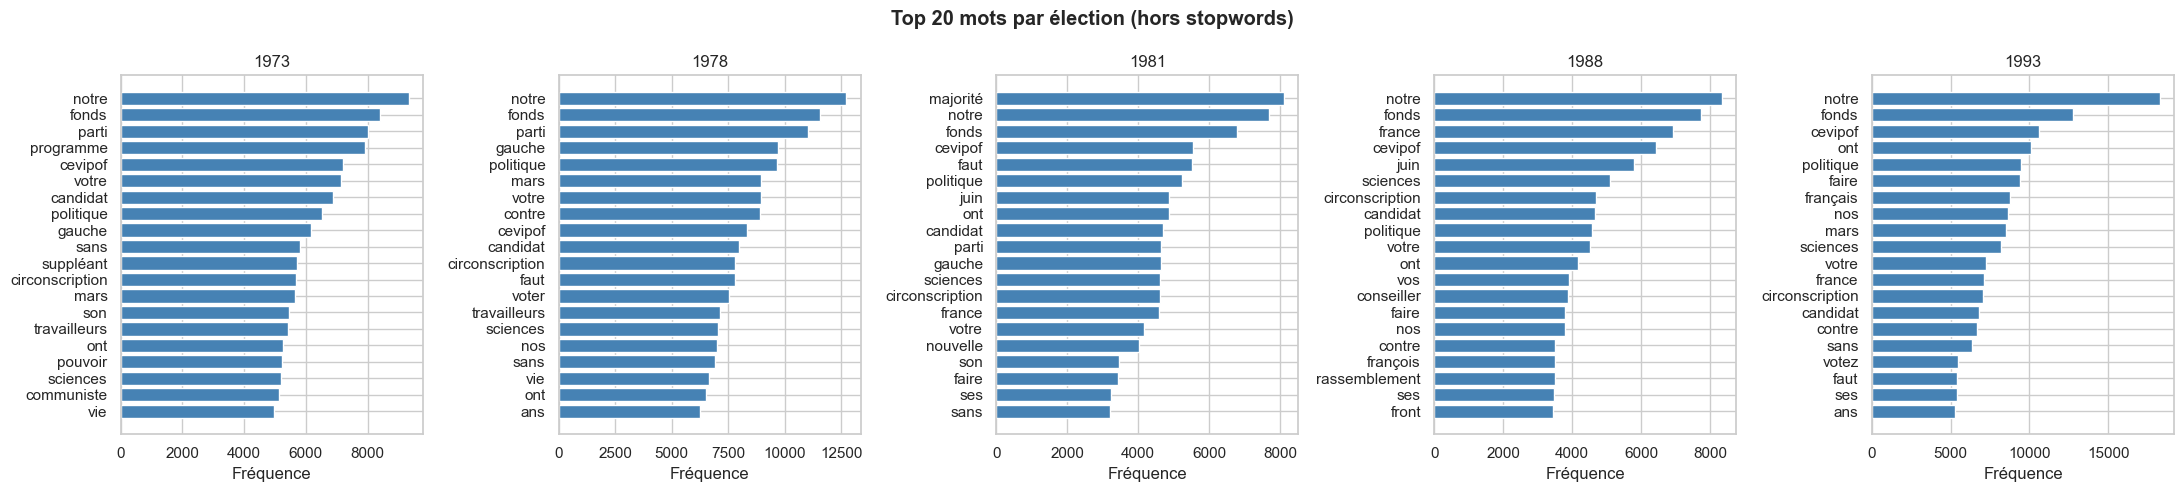

In [11]:
STOPWORDS = {'le','la','les','de','du','des','un','une','en','et','à','au','aux',
             'est','sont','pour','par','sur','dans','que','qui','se','il','elle',
             'nous','vous','ils','elles','on','je','me','mon','ma','mes','ce','cette',
             'ces','plus','ou','si','ne','pas','avec','comme','mais','tout','tous',
             'toute','toutes','leur','leurs','y','dont','où','être','avoir','je','--'}

fig, axes = plt.subplots(1, len(years), figsize=(22, 5))
for ax, year in zip(axes, years):
    texts = corpus[corpus['year'] == year]['text'].dropna().str.lower()
    words = [w for text in texts for w in text.split()
             if w.isalpha() and w not in STOPWORDS and len(w) > 2]
    top = Counter(words).most_common(20)
    words_list = [w for w, c in top][::-1]
    counts_list = [c for w, c in top][::-1]
    ax.barh(words_list, counts_list, color='steelblue')
    ax.set_title(f'{year}')
    ax.set_xlabel('Fréquence')

plt.suptitle('Top 20 mots par élection (hors stopwords)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/01_top_mots.png', dpi=150)
plt.show()

## 7. Exemple texte brut

In [12]:
for year in years:
    row = corpus[corpus['year'] == year].iloc[0]
    print(f'\n=== {year} — {row["document_id"]} ===')
    print(row['text'][:300])
    print('...')


=== 1973 — EL067_L_1973_03_059_10_1_PF_04 ===
10me Circonscription
Elections Législatives - 4 Mars 1973
POURQUOI UNE OPPOSITION GAULLISTE ?
La "majorité" a trompé les Français : élue, certes par la grande peur de 1968, mais aussi au nom du gaullisme, elle en a trahi les principes essentiels.
*
- L'Etat livré aux puissances d'argent et compromis
...

=== 1978 — EL102_L_1978_03_008_01_1_PF_05 ===
ELECTIONS LEGISLATIVES
Département des Ardennes
PREMIERE CIRCONSCRIPTION
Docteur Pierre VASSAL
DEUX HOMMES DE CHEZ NOUS QUI ONT FAIT LEURS PREUVES
Docteur Pierre VASSAL
- Médecin-expert, rhumatologie
- Délégué pour la France de l'Organisation Internationale des Experts
- Médecin Lieutenant-Colonel d
...

=== 1981 — EL137_L_1981_06_971_03_1_PF_04 ===
ELECTIONS LEGISLATIVES DES 14 ET 21 JUIN 1981
Electrices, Electeurs
de la 3eme Circonscription
Une ère nouvelle vient de commencer, un nouveau pouvoir politi- que a été mis en place. Nous y avons contribué. Il faut une autre politique, il faut des h

# Fréquence des mots "immigration", "sécurité", "chômage", "nation" par année

Text(0.5, 1.0, 'Evolution of keyword frequency')

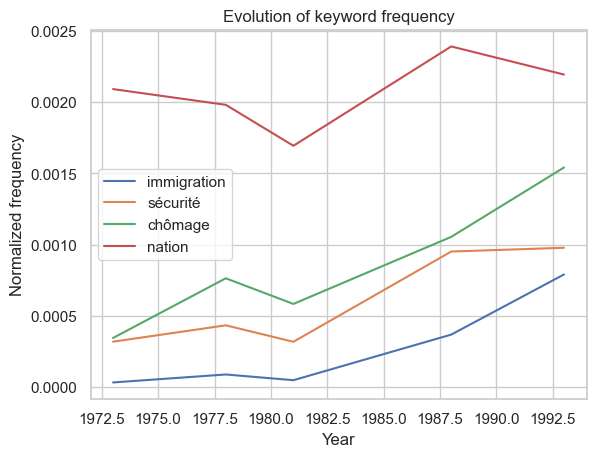

In [15]:
keywords = ["immigration", "sécurité", "chômage", "nation"]

freq = {word: [] for word in keywords}

for year in years:
    texts = corpus[corpus["year"] == year]["text"]
    total = sum(len(t.split()) for t in texts)
    
    for word in keywords:
        count = sum(t.count(word) for t in texts)
        freq[word].append(count / total)

for word in keywords:
    plt.plot(years, freq[word], label=word)

plt.legend()
plt.xlabel("Year")
plt.ylabel("Normalized frequency")
plt.title("Evolution of keyword frequency")